# Ejerciocio 1

## 1º Cargamos todos los archivos CSV en un mismo DataFrame y comprobamos si existen datos redundantes


In [79]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Ruta de la carpeta donde están los archivos CSV
ruta_carpeta = "./csvs_por_año"
# Obtenemos la lista de archivos CSV en la carpeta
archivos_csv = [archivo for archivo in os.listdir(ruta_carpeta) if archivo.endswith(".csv")]
# Leer y concatenar todos los archivos en un solo DataFrame
df_original = pd.concat([pd.read_csv(os.path.join(ruta_carpeta, archivo)) for archivo in archivos_csv], ignore_index=True)
#Eliminar datos redundantes.
df_original = df_original.drop_duplicates()



## 2º Calculamos la media diaria de cada partícula del aire y determinamos la calidad general del aire, considerando como referencia la peor categoría entre las cinco partículas evaluadas.

In [ ]:
df_media_diaria = df_original
# Convertimos la columna 'date' a tipo datetime.
df_media_diaria["date"] = pd.to_datetime(df["date"])
# Extraemos solo la fecha sin las horas.
df_media_diaria["date"] = df_media_diaria["date"].dt.date
#Definimos las partúculas para determinar la calidad del aire.
columnas_relevantes = ["PM25", "PM10", "NO_2", "O_3", "SO_2"]
#Agrupamos por día y calculamos la media diaria de las particulas.
df_media_diaria = df_media_diaria.groupby("date")[columnas_relevantes].mean().reset_index()



#Definimos los límites contaminantes:
limitesContaminantes = {
    "PM25": [15, 30, 55, 110],
    "PM10": [25, 50, 90, 180],
    "NO_2": [50, 100, 200, 400],
    "O_3": [60, 120, 180, 240],
    "SO_2": [50, 100, 350, 500]
}
# Función para clasificar la partículas del aire.
def clasificar_calidad(valor, limites):

    if valor <= limites[0]:
        return 1
    elif valor <= limites[1]:
        return 2
    elif valor <= limites[2]:
        return 3
    elif valor <= limites[3]:
        return 4
    else:
        return 5
# Aplicar la clasificación a cada contaminante
for contaminante, limites in limitesContaminantes.items():
    df_media_diaria[f"categoria_{contaminante}"] = df_media_diaria[contaminante].apply(lambda x: clasificar_calidad(x, limites))

#Diccionario para darle texto al valor numérico de la calidad.
diccionario_calidad = {
    1: "Muy Bueno",
    2: "Bueno",
    3: "Regular",
    4: "Malo",
    5: "Muy Malo"
}


# Determinar la calidad general del aire como la peor categoría entre los contaminantes.
df_media_diaria["Calidad_Aire_General"] = df_media_diaria[
    [f"categoria_{c}" for c in limitesContaminantes.keys()]
].max(axis=1)  # Toma la peor categoría.
df_media_diaria["Calidad_Aire_General"] = df_media_diaria["Calidad_Aire_General"].replace(diccionario_calidad)

#Generamos el csv con la calidad diariia del aire.
df_media_diaria.to_csv("calidad_aire_diaria.csv", index=False)

## 3º Generamos el gráfico.


Calidad_Aire_General
Bueno        3271
Muy Bueno    1573
Muy Malo     1136
Regular       328
Malo           22
Name: count, dtype: int64


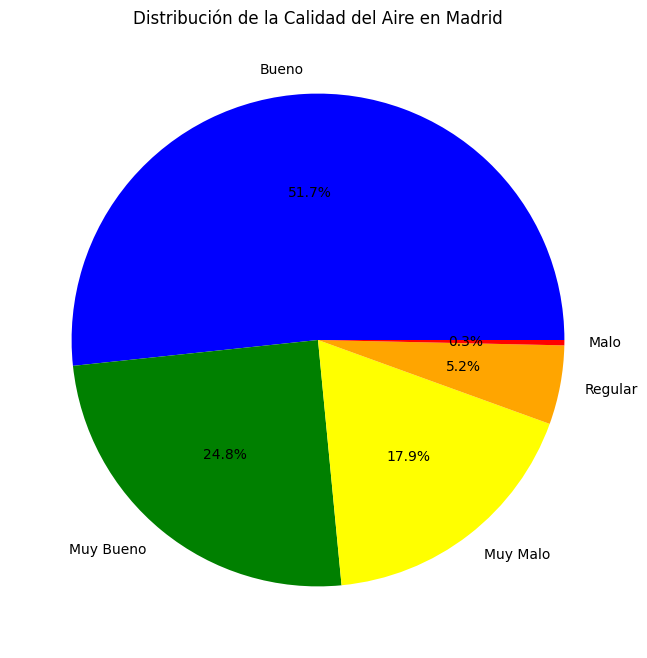

In [18]:
# Contamos la cantidad de días en cada categoría
conteo_calidades = df_media_diaria["Calidad_Aire_General"].value_counts()
print(conteo_calidades)

# Crear el gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(conteo_calidades, labels=conteo_calidades.index, autopct="%1.1f%%", colors=["blue", "green", "yellow", "orange", "red"])
plt.title("Distribución de la Calidad del Aire en Madrid")
plt.show()

## 4º Análisis del gráfico

El gráfico muestra que la mayoría de los días presentan condiciones aceptables: el 51,7% fueron "Buenos" y el 24,8% "Muy Buenos", lo que significa que más del 76% de los días tuvieron una calidad de aire favorable.
En contraste, los días con niveles preocupantes fueron menos frecuentes, con un 17,9% "Muy Malo", un 5,2% como "Regular" y solo un 0,3% como "Malo". Aunque este gráfico solo refleja la media diaria sin segmentar por año,
la alta proporción de días con buena calidad sugiere una posible mejora en la contaminación atmosférica. Sin embargo, para determinar si las medidas implementadas en 2016 tuvieron un impacto real, habría que analizar la
evolución año a año y comparar la tendencia antes y después de esa fecha.

## 5º Análisis por meses

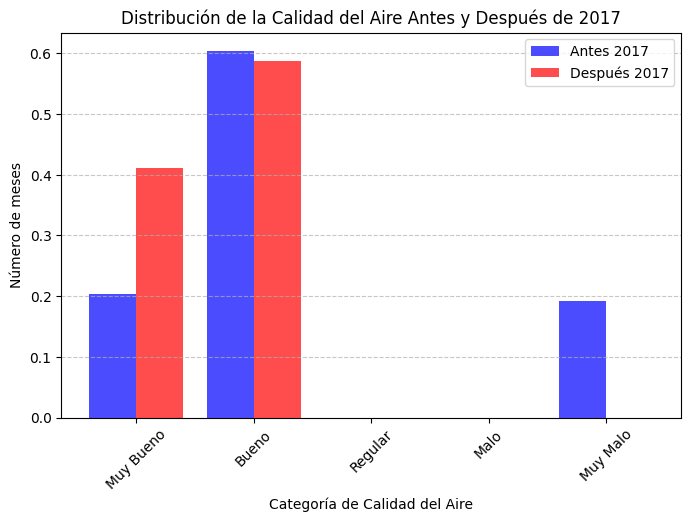

In [82]:
df_mes = df_original
# Convertimos la columna 'date' a tipo datetime
df_mes["date"] = pd.to_datetime(df_mes["date"])
# Extraemos solo el año y mes
df_mes["year_month"] = df_mes["date"].dt.to_period("M")
#Agrupamos por año y mes y calculamos la media mensual de las partículas.
df_mes = df_mes.groupby("year_month")[columnas_relevantes].mean().reset_index()

# Aplicamos la clasificación a cada contaminante
for contaminante, limites in limitesContaminantes.items():
    df_mes[f"categoria_{contaminante}"] = df_mes[contaminante].apply(lambda x: clasificar_calidad(x, limites))

# Determinar la calidad general del aire como la peor categoría entre los contaminantes.
df_mes["Calidad_Aire_General"] = df_mes[
    [f"categoria_{c}" for c in limitesContaminantes.keys()]
].max(axis=1)  # Toma la peor categoría.
df_mes["Calidad_Aire_General"] = df_mes["Calidad_Aire_General"].replace(diccionario_calidad)

#Generamos el csv con la calidad mensual del aire del aire.
df_mes.to_csv("calidad_aire_mensual.csv", index=False)


#Separamos las medidas en antes y después de las medidas
calidad_antes_2017 = df_mes[df_mes["year_month"] < "2017-01"]["Calidad_Aire_General"].value_counts()
calidad_despues_2017 = df_mes[df_mes["year_month"] >= "2017-01"]["Calidad_Aire_General"].value_counts()

#Normalizamos las proporciones
calidad_antes_2017 /= calidad_antes_2017.sum()
calidad_despues_2017 /= calidad_despues_2017.sum()

# Orden de las categorías
categorias = ["Muy Bueno", "Bueno", "Regular", "Malo", "Muy Malo"]
valores_antes = [calidad_antes_2017.get(cat, 0) for cat in categorias]
valores_despues = [calidad_despues_2017.get(cat, 0) for cat in categorias]

# Creamos el gráfico de barras
plt.figure(figsize=(8, 5))
width = 0.4
x = range(len(categorias))

plt.bar(x, valores_antes, width=width, label="Antes 2017", color="blue", alpha=0.7)
plt.bar([i + width for i in x], valores_despues, width=width, label="Después 2017", color="red", alpha=0.7)

plt.xticks([i + width/2 for i in x], categorias, rotation=45)
plt.xlabel("Categoría de Calidad del Aire")
plt.ylabel("Número de meses")
plt.title("Distribución de la Calidad del Aire Antes y Después de 2017")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


## 5.1º Análisis diagrama de barras.

El gráfico sugiere que las restricciones de tráfico mejoraron la calidad del aire. Antes de 2017, había meses con calidad "Muy Malo", pero después desaparecieron, mientras que la categoría "Muy Bueno" aumentó notablemente. La categoría "Bueno" se mantiene estable, indicando que la mejora se refleja más en la reducción de contaminación extrema. En general, la disminución de las categorías más contaminadas y el aumento de los meses con mejor calidad del aire sugieren que las medidas fueron efectivas.


## 6º Análisis anual.

Para llevar a cabo el análisis anual, realizaremos un diagrama de cajas para cada partícula. En este diagrama se incluirán todas las mediciones registradas a lo largo de cada año, lo que permitirá visualizar la distribución de los datos de forma clara y detallada. 

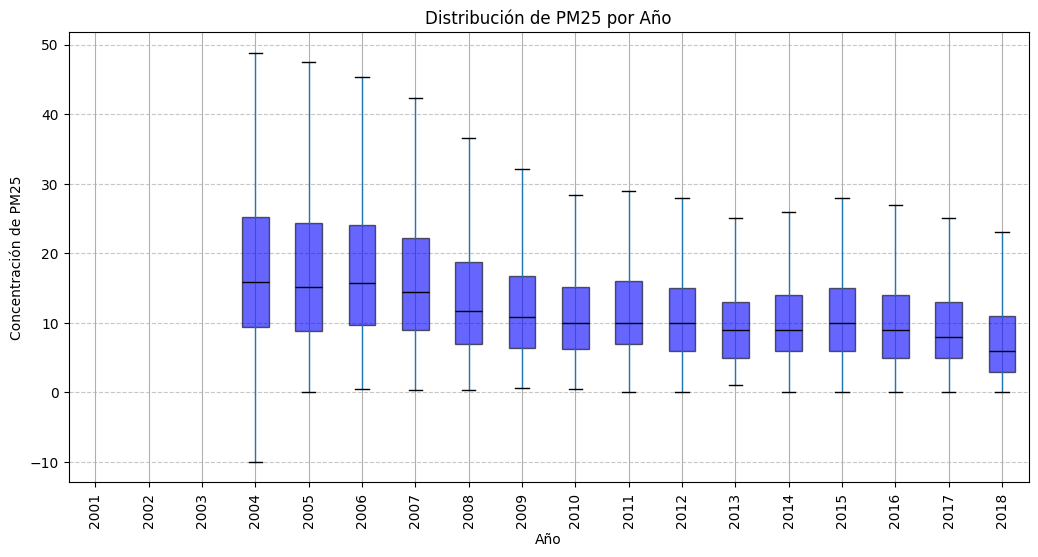

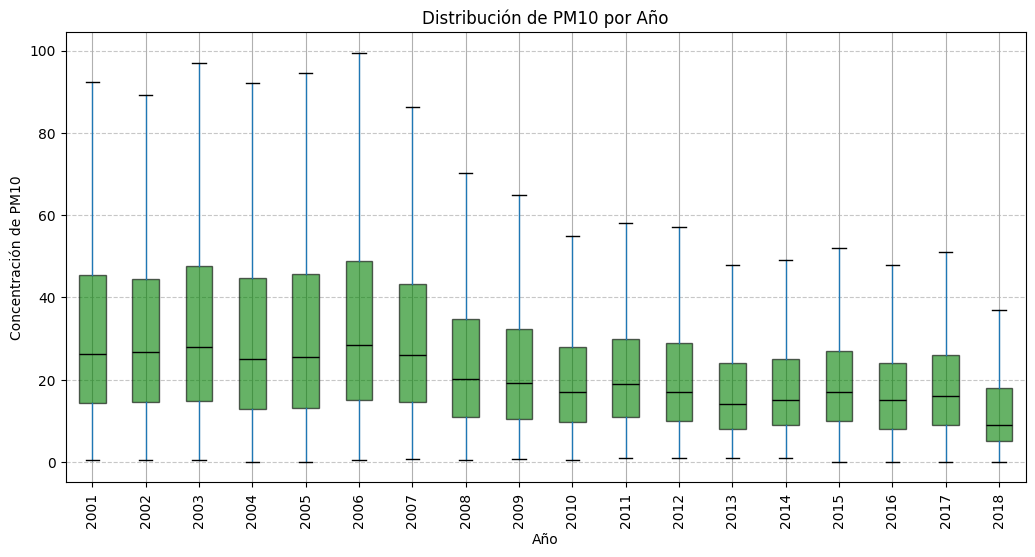

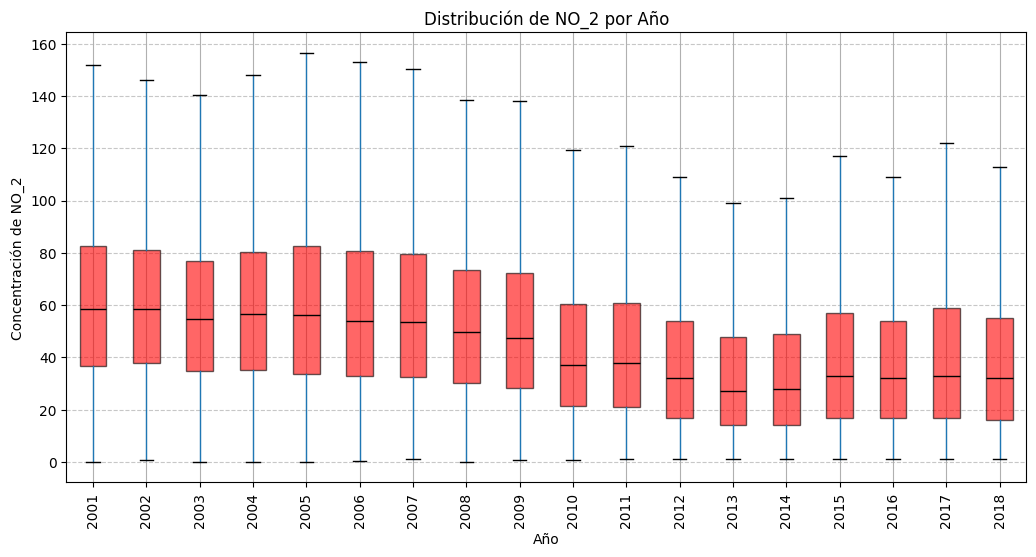

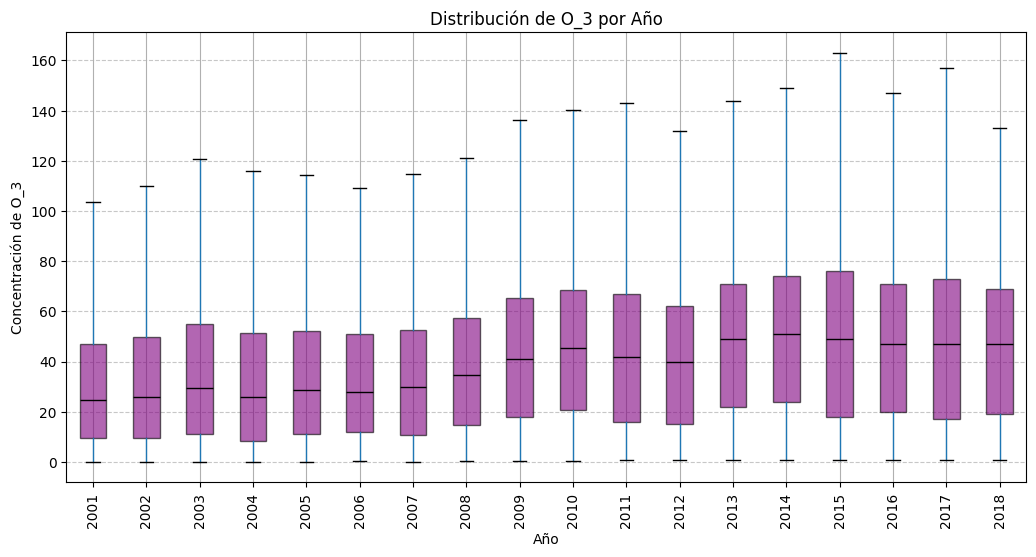

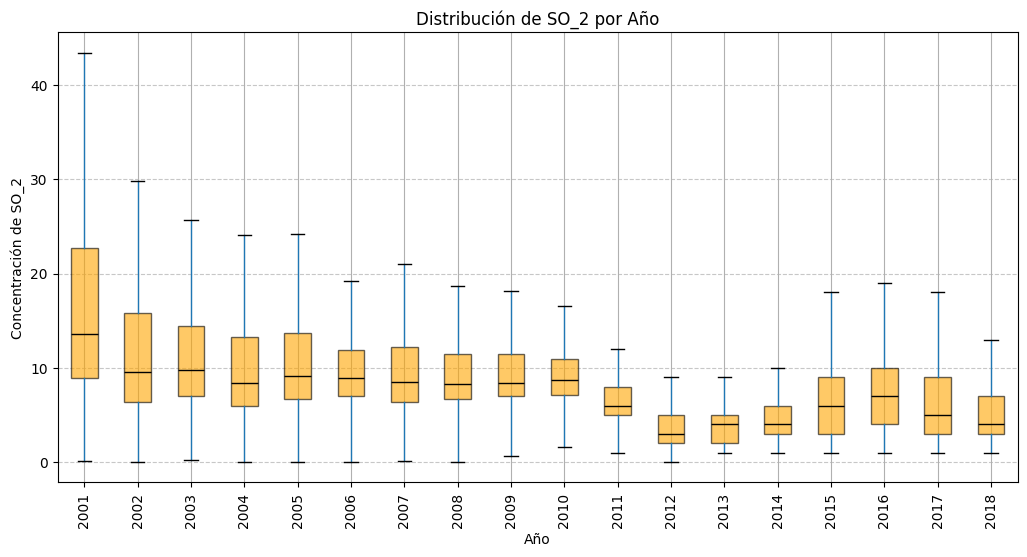

In [110]:
df_analisis = df_original
df_analisis["date"] = pd.to_datetime(df_analisis["date"])
df_analisis["year"] = df_analisis["date"].dt.year

# Colores para cada contaminante
colores = ["blue", "green", "red", "purple", "orange"]  

# Definir el ancho de las cajas y su posición
ancho_caja = 0.3
años = sorted(df_analisis["year"].unique()) 
posiciones = list(range(len(años)))  # Posiciones para cada año

for i, contaminante in enumerate(columnas_relevantes):
    fig, ax = plt.subplots(figsize=(12, 6))  # Crear nueva figura para cada contaminante

    # Generar el boxplot para el contaminante actual
    df_analisis.boxplot(column=contaminante, by="year", 
                        positions=posiciones, widths=0.5, patch_artist=True, 
                        showfliers=False, boxprops=dict(facecolor=colores[i], alpha=0.6), 
                        medianprops=dict(color="black"), ax=ax)

    # Mejorar diseño
    ax.set_title(f"Distribución de {contaminante} por Año")
    fig.suptitle("")  # Eliminar título automático
    ax.set_xlabel("Año")
    ax.set_ylabel(f"Concentración de {contaminante}")

    # Configurar los ticks del eje X con los últimos 2 dígitos del año y rotarlos
    ax.set_xticks(posiciones)
    ax.set_xticklabels(años, rotation=90)

    ax.grid(axis="y", linestyle="--", alpha=0.7)

    # Mostrar el gráfico de este contaminante
    plt.show()


## 6.1º Análisis de los gráficos.

